### Quality check analysis of anndata object from re-mapped E-MTAB-8901 samples
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Creation date:** 11th of November 2024
- **Last modified date:** 11th of November 2024

### Import packages

In [1]:
import scanpy as sc
import scrublet as scr
import numpy as np
import pandas as pd
import sctk
import muon as mu
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns

2024-11-12 12:06:16.177538: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-12 12:06:16.177579: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-12 12:06:16.177615: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-12 12:06:16.830927: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Set up parameters to save plots and objects

In [ ]:
project = 'gut'
species = 'hs'
atribute = 'Elementaite2021_E-MTAB-8901'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
counts = 'raw'

### Load data

In [2]:
adata = sc.read_h5ad('raw_data/Elmentaite_2021/gut_hs_Elementaite2021_E-MTAB-8901_AM_25102024_145319_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 40550400 × 70711
    obs: 'sample_name', 'batch', 'barcode', 'Source Name', 'Comment[ENA_SAMPLE]', 'Comment[BioSD_SAMPLE]', 'Characteristics[organism]', 'Characteristics[developmental stage]', 'Characteristics[age]', 'Unit[time unit]', 'Term Source REF', 'Term Accession Number', 'Characteristics[gestational age]', 'Unit[time unit].1', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[sex]', 'Characteristics[disease]', 'Characteristics[individual]', 'Characteristics[organism part]', 'Characteristics[cell type]', 'Characteristics[immunophenotype]', 'Characteristics[growth condition]', 'Characteristics[passage]', 'Material Type', 'Protocol REF', 'Protocol REF.1', 'Protocol REF.2', 'Protocol REF.3', 'Protocol REF.4', 'Extract Name', 'Comment[LIBRARY_LAYOUT]', 'Comment[LIBRARY_SELECTION]', 'Comment[LIBRARY_SOURCE]', 'Comment[LIBRARY_STRAND]', 'Comment[LIBRARY_STRATEGY]', 'Comment[NOMINAL_LENGTH]', 'Comment[NOMINAL_SDEV]', 'Comment[ORIENTAT

### Basic filtering

In [3]:
sc.pp.filter_cells(adata, min_genes=100)
adata

AnnData object with n_obs × n_vars = 1133590 × 70711
    obs: 'sample_name', 'batch', 'barcode', 'Source Name', 'Comment[ENA_SAMPLE]', 'Comment[BioSD_SAMPLE]', 'Characteristics[organism]', 'Characteristics[developmental stage]', 'Characteristics[age]', 'Unit[time unit]', 'Term Source REF', 'Term Accession Number', 'Characteristics[gestational age]', 'Unit[time unit].1', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[sex]', 'Characteristics[disease]', 'Characteristics[individual]', 'Characteristics[organism part]', 'Characteristics[cell type]', 'Characteristics[immunophenotype]', 'Characteristics[growth condition]', 'Characteristics[passage]', 'Material Type', 'Protocol REF', 'Protocol REF.1', 'Protocol REF.2', 'Protocol REF.3', 'Protocol REF.4', 'Extract Name', 'Comment[LIBRARY_LAYOUT]', 'Comment[LIBRARY_SELECTION]', 'Comment[LIBRARY_SOURCE]', 'Comment[LIBRARY_STRAND]', 'Comment[LIBRARY_STRATEGY]', 'Comment[NOMINAL_LENGTH]', 'Comment[NOMINAL_SDEV]', 'Comment[ORIENTATI

### Doublet score prediction

In [4]:
sample_names = adata.obs['Source Name'].unique()

for sample_name in sample_names:
    mask = adata.obs['Source Name'] == sample_name
    sample_adata = adata[mask].copy()

    scrub = scr.Scrublet(sample_adata.X)

    sample_adata.obs['doublet_scores'], sample_adata.obs['predicted_doublets'] = scrub.scrub_doublets()

    adata.obs.loc[mask, 'doublet_scores'] = sample_adata.obs['doublet_scores']
    adata.obs.loc[mask, 'predicted_doublets'] = sample_adata.obs['predicted_doublets']

    #scrub.plot_histogram()

    #plt.show()

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.21
Detected doublet rate = 21.7%
Estimated detectable doublet fraction = 49.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 44.0%
Elapsed time: 93.7 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.30
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 0.0%
Elapsed time: 3.2 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.34
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 0.0%
Elapsed time: 5.5 seconds
Preprocessing...
Simulating doubl

In [5]:
doub_tab = pd.crosstab(adata.obs['Source Name'],adata.obs['predicted_doublets'])
doub_tab.sum()

predicted_doublets
False    927692
True     113634
dtype: int64

In [6]:
doub_tab_percentage = doub_tab.div(doub_tab.sum(axis=1), axis=0) * 100

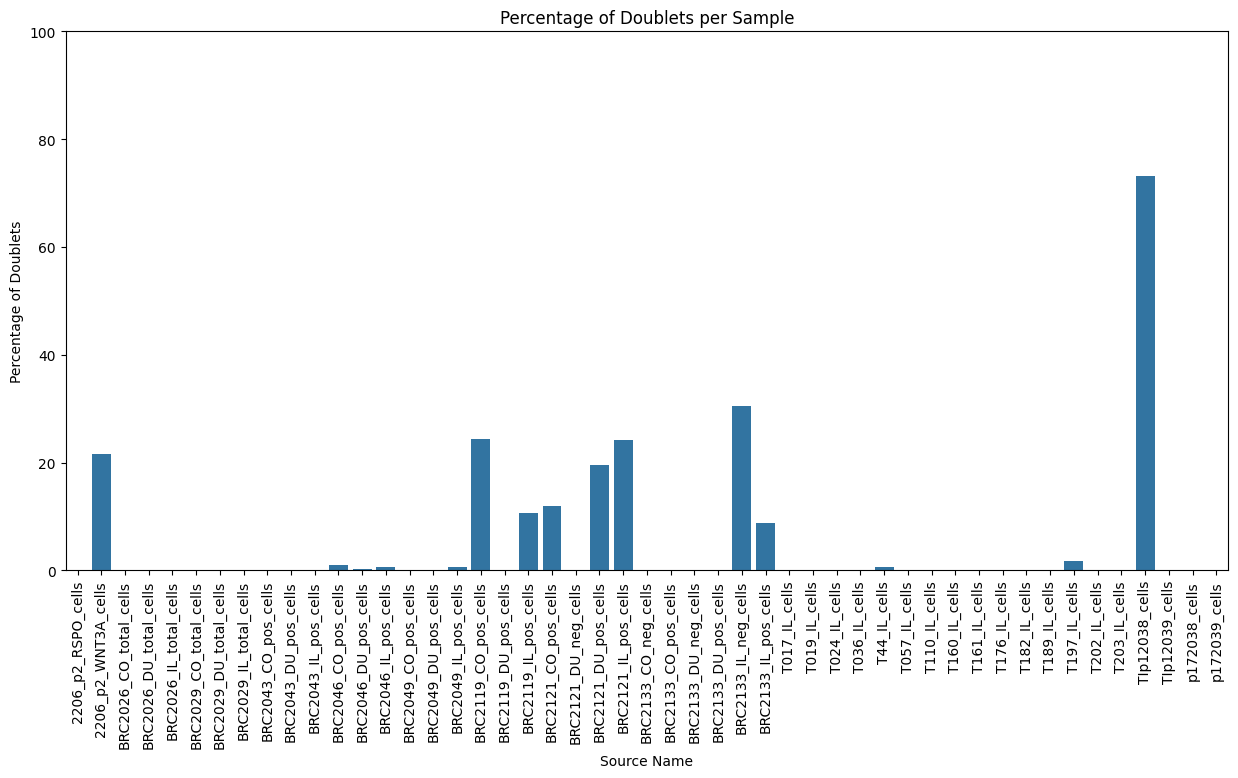

In [7]:
plt.figure(figsize=(15, 7), dpi = 300)
sns.barplot(x=doub_tab_percentage.index, y=doub_tab_percentage[(True)])
plt.ylim(0, 100)
plt.xticks(rotation=90)
plt.xlabel('Source Name')
plt.ylabel('Percentage of Doublets')
plt.title('Percentage of Doublets per Sample')
plt.savefig('raw_data/Elmentaite_2021/resulted_plot/{atribute}_scrublet_doublets_{timestamp}_.png')
plt.show()

### Quality Check

+ Calculate QC metrics

In [8]:
sctk.calculate_qc(adata)
adata

AnnData object with n_obs × n_vars = 1133590 × 70711
    obs: 'sample_name', 'batch', 'barcode', 'Source Name', 'Comment[ENA_SAMPLE]', 'Comment[BioSD_SAMPLE]', 'Characteristics[organism]', 'Characteristics[developmental stage]', 'Characteristics[age]', 'Unit[time unit]', 'Term Source REF', 'Term Accession Number', 'Characteristics[gestational age]', 'Unit[time unit].1', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[sex]', 'Characteristics[disease]', 'Characteristics[individual]', 'Characteristics[organism part]', 'Characteristics[cell type]', 'Characteristics[immunophenotype]', 'Characteristics[growth condition]', 'Characteristics[passage]', 'Material Type', 'Protocol REF', 'Protocol REF.1', 'Protocol REF.2', 'Protocol REF.3', 'Protocol REF.4', 'Extract Name', 'Comment[LIBRARY_LAYOUT]', 'Comment[LIBRARY_SELECTION]', 'Comment[LIBRARY_SOURCE]', 'Comment[LIBRARY_STRAND]', 'Comment[LIBRARY_STRATEGY]', 'Comment[NOMINAL_LENGTH]', 'Comment[NOMINAL_SDEV]', 'Comment[ORIENTATI

+ Determine which of the cells pass QC individually

In [9]:
sctk.cellwise_qc(adata)
adata

n_counts: [928.8964661186179, 122812.0], 197113/1133590 passed
n_genes: [99.9999893018715, 8409.0029296875], 1133590/1133590 passed
percent_mito: [0.0, 15.093082076790603], 1056667/1133590 passed
percent_ribo: [16.891844850252014, 66.34882397373183], 1092235/1133590 passed
percent_hb: [0.0, 0.009187026144773716], 796797/1133590 passed
111040/1133590 pass


AnnData object with n_obs × n_vars = 1133590 × 70711
    obs: 'sample_name', 'batch', 'barcode', 'Source Name', 'Comment[ENA_SAMPLE]', 'Comment[BioSD_SAMPLE]', 'Characteristics[organism]', 'Characteristics[developmental stage]', 'Characteristics[age]', 'Unit[time unit]', 'Term Source REF', 'Term Accession Number', 'Characteristics[gestational age]', 'Unit[time unit].1', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[sex]', 'Characteristics[disease]', 'Characteristics[individual]', 'Characteristics[organism part]', 'Characteristics[cell type]', 'Characteristics[immunophenotype]', 'Characteristics[growth condition]', 'Characteristics[passage]', 'Material Type', 'Protocol REF', 'Protocol REF.1', 'Protocol REF.2', 'Protocol REF.3', 'Protocol REF.4', 'Extract Name', 'Comment[LIBRARY_LAYOUT]', 'Comment[LIBRARY_SELECTION]', 'Comment[LIBRARY_SOURCE]', 'Comment[LIBRARY_STRAND]', 'Comment[LIBRARY_STRATEGY]', 'Comment[NOMINAL_LENGTH]', 'Comment[NOMINAL_SDEV]', 'Comment[ORIENTATI

In [10]:
adata.obs['cell_passed_qc'].sum()

111040

In [11]:
adata.uns['scautoqc_ranges']

,low,high
n_counts,928.896466,122812.0
n_genes,99.999989,8409.00293
percent_mito,0.0,15.093082
percent_ribo,16.891845,66.348824
percent_hb,0.0,0.009187


+ Check the QC parameters (default parameters)

In [12]:
sctk.default_metric_params_df

,min,max,scale,side,min_pass_rate
n_counts,1000.00,NaN,log,min_only,0.10
n_genes,100.00,NaN,log,min_only,0.10
percent_mito,0.01,20.0,log,max_only,0.10
percent_ribo,0.00,100.0,log,both,0.10
percent_hb,NaN,1.0,log,max_only,0.10
percent_soup,NaN,5.0,log,max_only,0.10
percent_spliced,50.00,97.5,log,both,0.10
scrublet_score,NaN,0.3,linear,max_only,0.95


+ Cluster cells based on their QC

In [13]:
metrics_list = ["log1p_n_counts", "log1p_n_genes", "percent_mito", "percent_ribo", "percent_hb"]
sctk.generate_qc_clusters(adata, metrics = metrics_list)
adata

KeyboardInterrupt: 

In [ ]:
sc.pl.embedding(adata, "X_umap_qc", color=["qc_cluster", "log1p_n_counts", "log1p_n_genes",
                                            "percent_mito", "percent_ribo", "percent_hb"], 
                                            color_map="magma_r", frameon=False, ncols=3)

In [ ]:
sctk.clusterwise_qc(adata)
adata

In [ ]:
sc.pl.embedding(adata, "X_umap_qc", color=["cell_passed_qc", "cluster_passed_qc"])

In [ ]:
sctk.multi_resolution_cluster_qc(adata, metrics = metrics_list)

In [ ]:
sc.pl.embedding(adata, "X_umap_qc", color=["cell_passed_qc", 
                                           "cluster_passed_qc", 
                                           "consensus_fraction", 
                                           "consensus_passed_qc"])

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=adata.obs, x='total_counts', y='n_genes_by_counts' , hue ='sample', alpha = 0.4, s=4)
plt.legend(title='sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(0, int(max(adata.obs['total_counts'])) + 1, 3000),rotation=45, fontsize = 10)
plt.yticks(range(0, int(max(adata.obs['n_genes_by_counts'])) + 1, 1000),fontsize = 10)
plt.title(f'Counts vs Genes - Before filtering')
plt.show()

### Sex covariate analysis

In [ ]:
annot = sc.queries.biomart_annotations(
        "hsapiens",
        ["ensembl_gene_id", "external_gene_name", "start_position", "end_position", "chromosome_name"],
    ).set_index("external_gene_name")

* Chr Y genes calculation

In [ ]:
chrY_genes = adata.var_names.intersection(annot.index[annot.chromosome_name == "Y"])

AnnData object with n_obs × n_vars = 188253 × 32285
    obs: 'sample', 'genotype', 'batch', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [ ]:
adata.obs['percent_chrY'] = np.sum(
    adata[:, chrY_genes].X, axis = 1) / np.sum(adata.X, axis = 1) * 100

+ XIST expression analysis

In [ ]:
xist_counts = adata.X[:, adata.var_names.str.match('XIST')].toarray()

In [ ]:
xist_percentage = (np.sum(xist_counts, axis=1) / adata.obs['total_counts']) * 100

In [ ]:
xist_counts_series = pd.Series(xist_counts.squeeze(), index = adata.obs_names, name = "XIST-counts")
xist_percentage_series = pd.Series(xist_percentage, index=adata.obs_names, name="percent_XIST")

adata.obs["XIST-counts"] = xist_counts_series
adata.obs["XIST-percentage"] = xist_percentage_series

In [ ]:
sc.pl.violin(adata, ["XIST-counts", "percent_chrY"], jitter = 0.4, groupby = 'sample', rotation = 45)

+ Calculate cell cycle score

In [ ]:
cell_cycle_genes = pd.read_csv('cell_cycle_gene/regev_lab_cell_cycle_genes.txt', sep='\t', header=None)

In [ ]:
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]
print(len(cell_cycle_genes))